## E4

## Parte 1

Lo primero, abrir geopandas y cargar el archivo de áreas urbanas. Luego, mostrar las primeras filas del dataframe.

Pueden trabajar en Google Colab preferentemente, para no tener problemas con geopandas. 

De todos modos, ya es posible instalar geopandas localmente, así que si quieren pueden hacerlo.


In [1]:
import geopandas as gpd

chile_urbano = gpd.read_file('datos_geoespaciales/Areas Urbanas/areas_urbanas.shp')

chile_urbano.head(10)

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
0,Chiguayante,Ciudad,29855.998337,1.038076e+07,"POLYGON ((140044.634 5911024.284, 140051.361 5..."
1,Lota,Ciudad,14233.349738,5.262642e+06,"POLYGON ((131359.666 5889462.902, 131475.343 5..."
2,Coronel,Ciudad,41577.791832,1.551685e+07,"POLYGON ((127278.44 5896965.436, 127411.675 58..."
3,San Rosendo,Ciudad,6499.369423,1.534402e+06,"POLYGON ((168583.83 5870293.97, 168725.579 587..."
4,Concepción,Ciudad,82986.894378,3.454227e+07,"POLYGON ((133504.854 5919782.212, 136052.58 59..."
5,Arica,Ciudad,39931.465240,2.150982e+07,"POLYGON ((363189.134 7961890.925, 363424.226 7..."
6,Iquique,Ciudad,64442.900734,2.464536e+07,"MULTIPOLYGON (((378467.969 7764956, 378467.25 ..."
7,Tocopilla,Ciudad,18321.064000,4.465189e+06,"POLYGON ((376927.626 7558000.68, 377009.49 755..."
8,Mejillones,Ciudad,17400.058444,7.553972e+06,"POLYGON ((355461.344 7446261.21, 355498.385 74..."
9,Taltal,Ciudad,7610.917978,2.074163e+06,"POLYGON ((351357.497 7190359.826, 351805.344 7..."


In [2]:
# entregar los valores de NOMBRE que empiezan con S
chile_urbano[chile_urbano['NOMBRE'].str.startswith('S')]

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
3,San Rosendo,Ciudad,6499.369423,1.534402e+06,"POLYGON ((168583.83 5870293.97, 168725.579 587..."
14,Salamanca,Ciudad,8567.079888,2.017757e+06,"POLYGON ((312732.654 6482812.622, 313075.541 6..."
45,San Gregorio,Pueblo,3788.267206,5.215228e+05,"POLYGON ((246626.618 5980451.726, 246617.559 5..."
63,San Patricio,Aldea,3996.741231,7.893037e+05,"POLYGON ((228343.568 5716137.461, 228506.552 5..."
117,Santa Juana,Ciudad,7493.799893,1.855266e+06,"POLYGON ((148738.479 5879466.45, 148907.791 58..."
120,San Fabian de Alico,Pueblo,3705.033233,6.431161e+05,"POLYGON ((271907.377 5950836.901, 271113.944 5..."
127,San Nicolas,Pueblo,4437.194024,9.024894e+05,"POLYGON ((211766.417 5956223.739, 212472.14 59..."
128,Santa Barbara,Ciudad,5842.563626,1.073795e+06,"POLYGON ((232670.262 5826380.347, 232746.172 5..."
138,San Pedro,Ciudad,34816.402270,2.233891e+07,"POLYGON ((130889.214 5909206.096, 130012.009 5..."
141,San Carlos,Ciudad,14510.505225,6.058379e+06,"POLYGON ((233165.049 5965710.539, 233773.218 5..."


Vemos que aparece Santiago, como MultiPolygon.

In [3]:
santiago_urbano = chile_urbano[chile_urbano['NOMBRE'] == 'Santiago']
santiago_urbano.head(10)

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
385,Santiago,Ciudad,427491.444262,5.821041e+08,"MULTIPOLYGON (((338445.291 6306151.222, 338289..."


<Axes: >

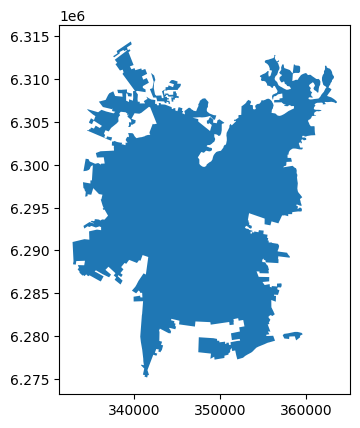

In [4]:
santiago_urbano.plot()

Es razonable, así luce Santiago Urbano.

In [5]:
santiago_urbano.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### a) Define una métrica de nivel socioeconómico que resuma los grupos E, D, C3, C2 y ABC1 en una sola variable.

### Utilice luego esta metrica para clasificar los distritos en niveles ”Bajo”, ”Medio” y ”Alto” segun estime conveniente, apoyandose en los datos. Grafique esta clasificacion en un mapa de los distritos censales

El tema es que el geodataframe que tenemos no tiene nada de info. socioeconómica. Entonces, lo que hay que hacer es buscar un dataset con info. relevante a nivel distrital, y luego unirlo con el geodataframe de áreas urbanas usando el código de comuna como clave.

Si se fijan, tenemos Distritos Censales.

In [6]:
distritos_censales = gpd.read_file('datos_geoespaciales/Distritos Censales/Distritos Censales RM.shp')
distritos_censales.head(10)

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6..."
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345880.28 6299633.958, 345961.61 629..."
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345546.017 6299748.84, 345650.511 62..."
3,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((344856.32 6298892.632, 345672.277 62..."
4,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,1310105.0,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((343856.526 6298225.435, 344041.982 6..."
5,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Portales,1310106.0,81.0,741.0,1268.0,1096.0,151.0,3337.0,618570.13,53.95,8.91,"POLYGON ((344853.057 6298944.84, 344856.32 629..."
6,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Matucana,1310107.0,50.0,602.0,812.0,559.0,98.0,2121.0,556810.27,38.09,7.50,"POLYGON ((344068.795 6300113.777, 344120.709 6..."
7,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,San Saturnino,1310108.0,97.0,810.0,1078.0,910.0,162.0,3057.0,668277.97,45.74,6.35,"POLYGON ((344555.979 6299948.258, 344776.355 6..."
8,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Mapocho,1310109.0,127.0,868.0,1167.0,762.0,148.0,3072.0,817926.27,37.56,7.45,"POLYGON ((344571.742 6300151.728, 344916.682 6..."
9,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Vicuña Mackenna,1310110.0,28.0,394.0,1225.0,1674.0,444.0,3765.0,592695.23,63.52,18.44,"POLYGON ((347488.43 6298672.836, 347569.109 62..."


In [7]:
distritos_censales.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Solo para cerciorarnos, usamos el mismo crs en ambos

In [8]:
santiago_urbano.to_crs(32719)

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
385,Santiago,Ciudad,427491.444262,5.821041e+08,"MULTIPOLYGON (((338445.291 6306151.222, 338289..."


In [9]:
santiago_urbano.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Ahora para mezclar ambos geodfs, la idea es usar Overlay para quedarnos solo con los distritos censales que se intersectan con el área urbana de Santiago.

In [10]:
intersection_stgo_urbano_distritos = gpd.overlay(santiago_urbano, distritos_censales, how='intersection')
intersection_stgo_urbano_distritos

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,...,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry
0,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,...,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346788.392 6299461.792, 346943.942 6..."
1,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,...,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345961.61 6299612.269, 346298.704 62..."
2,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,...,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345650.511 6299703.57, 345809.442 62..."
3,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,...,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((345672.277 6298980.643, 345689.082 6..."
4,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,...,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((344041.982 6298246.207, 344940.918 6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Nogales,...,210.0,1726.0,1711.0,911.0,72.0,4630.0,2114725.49,21.89,3.40,"POLYGON ((340825.997 6281439.993, 341160.856 6..."
336,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Tejas de Chena,...,475.0,2269.0,1846.0,750.0,61.0,5401.0,1771750.98,30.48,3.84,"POLYGON ((340901.38 6282439.427, 340932.1 6282..."
337,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Chena,...,165.0,1424.0,1779.0,1044.0,124.0,4536.0,34934099.30,1.30,0.68,"MULTIPOLYGON (((341046.208 6284092.881, 339946..."
338,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Estación,...,320.0,1702.0,1119.0,349.0,19.0,3509.0,894566.54,39.23,2.70,"POLYGON ((343007.242 6280895.568, 343001.004 6..."


Ahora, hay varias formas de definir la métrica de nivel socioeconómico. Por ejemplo, podrían usar el porcentaje de población en cada grupo socioeconómico, o podrían asignar un puntaje a cada grupo (por ejemplo, E=1, D=2, C3=3, C2=4, ABC1=5) y luego calcular un promedio ponderado.

Hagamos eso:

Primero, creamos una nueva columna que sume desde E hasta ABC1, y luego dividimos por el total de población para obtener el porcentaje de población en cada grupo socioeconómico.

In [11]:
total_poblacion = \
    intersection_stgo_urbano_distritos['E'] + \
    intersection_stgo_urbano_distritos['D'] + \
    intersection_stgo_urbano_distritos['C3'] + \
    intersection_stgo_urbano_distritos['C2'] + \
    intersection_stgo_urbano_distritos['ABC1']

Ahora, creamos la suma ponderada por la representatividad de cada grupo socioeconómico y un peso definido por nosotros. Por ejemplo, podríamos asignar un peso de 1 a E, 2 a D, 3 a C3, 4 a C2 y 5 a ABC1. 
También, podríamos meter el precio de 1 M2.

La idea igual es que las escalas de cada variable sean similares, para que ninguna domine sobre las otras. Por eso, es importante normalizar o estandarizar las variables antes de sumarlas. En este caso, hacemos una normalización min-max para que los valores queden entre 0 y 1.

In [12]:
intersection_stgo_urbano_distritos['indice_nse'] = (
    1 * intersection_stgo_urbano_distritos['E'] +
    2 * intersection_stgo_urbano_distritos['D'] +
    3 * intersection_stgo_urbano_distritos['C3'] +
    4 * intersection_stgo_urbano_distritos['C2'] +
    5 * intersection_stgo_urbano_distritos['ABC1']
) / total_poblacion


intersection_stgo_urbano_distritos['indice_nse_norm'] = (
    (intersection_stgo_urbano_distritos['indice_nse'] - intersection_stgo_urbano_distritos['indice_nse'].min()) / (intersection_stgo_urbano_distritos['indice_nse'].max() - intersection_stgo_urbano_distritos['indice_nse'].min())
)

intersection_stgo_urbano_distritos['uf_norm'] = (
    (intersection_stgo_urbano_distritos['1_UF_M2'] - intersection_stgo_urbano_distritos['1_UF_M2'].min()) /
    (intersection_stgo_urbano_distritos['1_UF_M2'].max() - intersection_stgo_urbano_distritos['1_UF_M2'].min())
)

intersection_stgo_urbano_distritos['puntaje'] = (
    0.7 * intersection_stgo_urbano_distritos['indice_nse_norm'] +
    0.3 * intersection_stgo_urbano_distritos['uf_norm']
)

<Axes: >

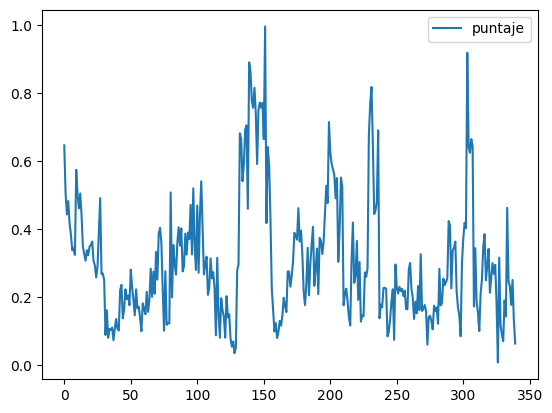

In [13]:
intersection_stgo_urbano_distritos['puntaje'].plot(column='puntaje', legend=True)

Ahora, podríamos decir que el puntaje si va entre 0 y 0.2 es Bajo, entre 0.2 y 0.6 es Medio, y entre 0.6 y 1 es Alto.

In [14]:
# aplicar clasificacion de nivel
def clasificar_nivel(puntaje):
    if puntaje < 0.2:
        return 'Bajo'
    elif puntaje < 0.6:
        return 'Medio'
    else:
        return 'Alto'
intersection_stgo_urbano_distritos['nivel_nse'] = intersection_stgo_urbano_distritos['puntaje'].apply(clasificar_nivel)
intersection_stgo_urbano_distritos.head(10)

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,...,ADIMARK_T,Area,Densidad,1_UF_M2,geometry,indice_nse,indice_nse_norm,uf_norm,puntaje,nivel_nse
0,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,...,3412.0,704315.75,48.44,31.09,"POLYGON ((346788.392 6299461.792, 346943.942 6...",3.488570,0.598632,0.754223,0.645309,Alto
1,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,...,2741.0,1166659.89,23.49,21.10,"POLYGON ((345961.61 6299612.269, 346298.704 62...",3.254287,0.501193,0.509670,0.503736,Medio
2,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,...,2387.0,509080.85,46.89,12.00,"POLYGON ((345650.511 6299703.57, 345809.442 62...",3.273146,0.509037,0.286903,0.442397,Medio
3,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,...,5062.0,761738.52,66.45,10.25,"POLYGON ((345672.277 6298980.643, 345689.082 6...",3.451798,0.583338,0.244064,0.481556,Medio
4,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,...,2899.0,765782.74,37.86,11.87,"POLYGON ((344041.982 6298246.207, 344940.918 6...",3.183167,0.471614,0.283721,0.415246,Medio
5,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Portales,...,3337.0,618570.13,53.95,8.91,"POLYGON ((344856.32 6298892.632, 344863.343 62...",3.148337,0.457129,0.211261,0.383368,Medio
6,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Matucana,...,2121.0,556810.27,38.09,7.50,"POLYGON ((344120.709 6299468.258, 344268.939 6...",3.024988,0.405828,0.176744,0.337103,Medio
7,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,San Saturnino,...,3057.0,668277.97,45.74,6.35,"POLYGON ((344776.355 6299869.902, 344849.608 6...",3.075237,0.426726,0.148592,0.343286,Medio
8,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Mapocho,...,3072.0,817926.27,37.56,7.45,"POLYGON ((344916.682 6300014.119, 345131.448 6...",2.979167,0.386771,0.175520,0.323395,Medio
9,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Vicuña Mackenna,...,3765.0,592695.23,63.52,18.44,"POLYGON ((347569.109 6298743.142, 347699.976 6...",3.560956,0.628737,0.444553,0.573482,Medio


C:\Users\jjacq\AppData\Local\Temp\ipykernel_18476\2470553487.py:3: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  intersection_stgo_urbano_distritos.plot(figsize=(10,10), column='nivel_nse', color=intersection_stgo_urbano_distritos['nivel_nse'].map(colores))


<Axes: >

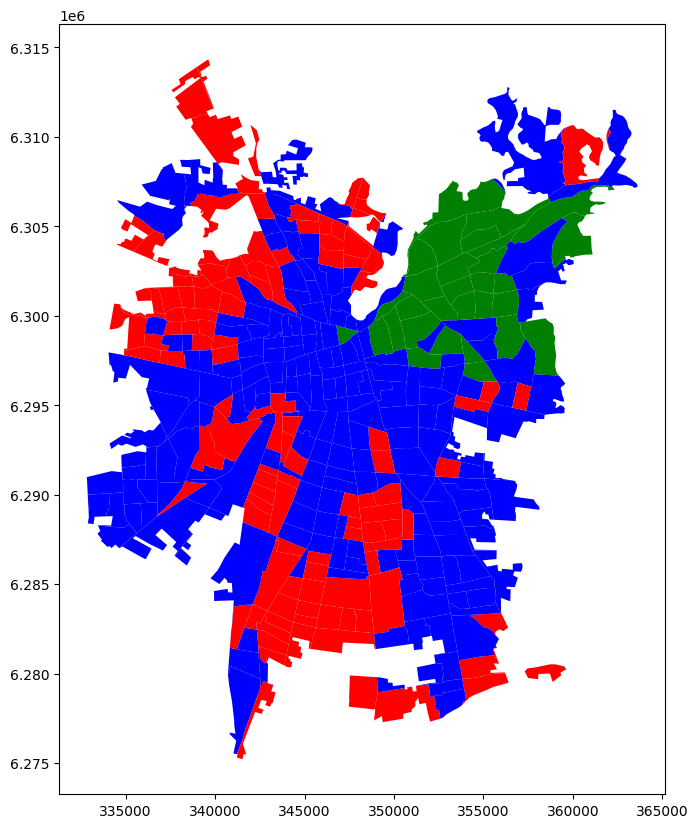

In [15]:
# plotear el nivel socioeconomico con colores fijos
colores = {'Bajo': 'red', 'Medio': 'blue', 'Alto': 'green'}
intersection_stgo_urbano_distritos.plot(figsize=(10,10), column='nivel_nse', color=intersection_stgo_urbano_distritos['nivel_nse'].map(colores))

### b) Encuentre las lineas de metro que atraviesan distritos con un nivel socioeconomico alto (definido en la mision anterior). Grafique en un mapa estas lineas y asigne un estilo especial a las secciones que pasan por areas de nivel alto para diferenciarlas de las otras. Incluya los distritos censales en la visualizacion.

In [16]:
metro_lineas = gpd.read_file('datos_geoespaciales/Metro 2020/Lineas_2020/Lineas_2020.shp')

In [17]:
metro_lineas

,OBJECTID,ID_LINEA,LINEA,LENGTH,Shape_Leng,Shape_Le_1,geometry
0,3,2,L2,18315.942,20087.016072,1301.975352,"LINESTRING (-70.66142 -33.52651, -70.66325 -33..."
1,4,2,L2,18315.942,20087.016072,1057.384032,"LINESTRING (-70.65881 -33.51723, -70.66138 -33..."
2,5,2,L2,18315.942,20087.016072,802.130950,"LINESTRING (-70.65682 -33.5102, -70.65865 -33...."
3,6,2,L2,18315.942,20087.016072,599.761286,"LINESTRING (-70.65315 -33.49734, -70.65346 -33..."
4,7,2,L2,18315.942,20087.016072,866.182956,"LINESTRING (-70.65465 -33.5026, -70.65679 -33...."
...,...,...,...,...,...,...,...
132,144,6,L6,0.000,15680.851666,15408.273451,"LINESTRING (-70.69536 -33.48342, -70.69189 -33..."
133,148,2,L2,0.000,0.000000,0.000000,"LINESTRING (-70.67355 -33.5714, -70.67585 -33...."
134,145,2,L2,0.000,0.000000,0.000000,"LINESTRING (-70.66432 -33.53736, -70.66627 -33..."
135,146,2,L2,0.000,0.000000,0.000000,"LINESTRING (-70.66667 -33.54632, -70.66791 -33..."


In [18]:
metro_lineas.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [19]:
metro_lineas = metro_lineas.to_crs(32719)

In [20]:
metro_lineas.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

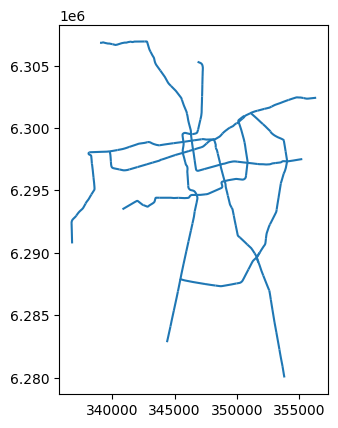

In [21]:
metro_lineas.plot()

1. Intersección espacial

In [22]:
metro_distritos = gpd.overlay(metro_lineas, intersection_stgo_urbano_distritos, how="intersection")

2. Filtrar zonas de alto NSE

In [23]:
metro_alto = metro_distritos[metro_distritos["nivel_nse"] == "Alto"].copy()
metro_otro = metro_distritos[metro_distritos["nivel_nse"] != "Alto"].copy()

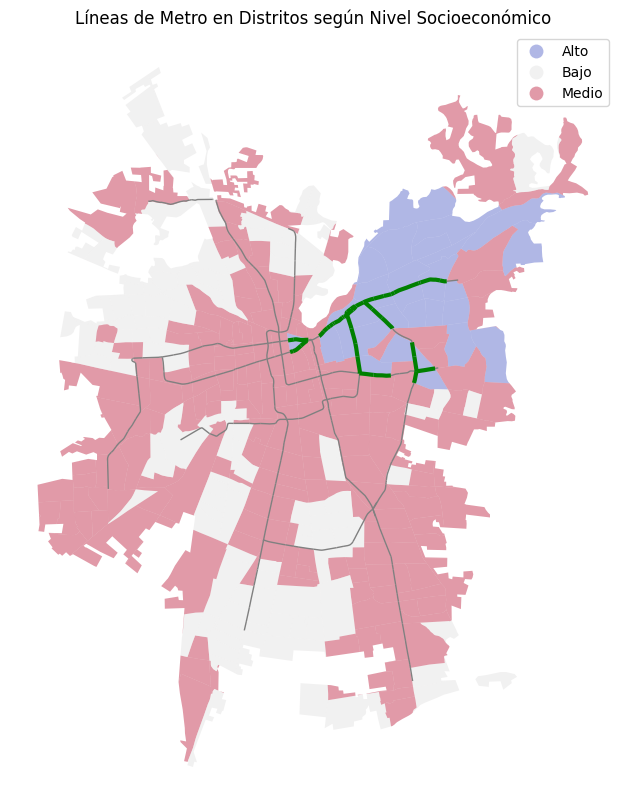

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

# distritos (fondo)
intersection_stgo_urbano_distritos.plot(
    column="nivel_nse",
    cmap="coolwarm",
    legend=True,
    alpha=0.4,
    ax=ax
)

# líneas NO alto
metro_otro.plot(ax=ax, color="gray", linewidth=1)

# líneas en zonas ALTO
metro_alto.plot(ax=ax, color="green", linewidth=3)

plt.title("Líneas de Metro en Distritos según Nivel Socioeconómico")
plt.axis("off")
plt.show()

### Extra (fuera del ejercicio): Identificar qué líneas pasan más por zonas “Alto”

In [25]:
metro_alto["length_calc"] = metro_alto.geometry.length

metro_alto.groupby("LINEA")["length_calc"].sum().sort_values(ascending=False)

LINEA
L1    9189.677684
L4    4473.384501
L6    4112.884514
L3    2888.483299
L5    1141.724099
Name: length_calc, dtype: float64

### c) Calcule un indice de accesibilidad al metro para cada distrito de la Region Metropolitana. Este indice debe reflejar la cantidad de estaciones de metro a distancia caminable (1000m) del centroide del distrito. Clasifıquelos cuatro niveles de accesibilidad segun el criterio que estime conveniente. Visualice el resultado en un mapa en donde se vean los niveles de accesibilidad por distrito y las estaciones de metro.

In [26]:
centroides_distritos = gpd.read_file('datos_geoespaciales/Distritos Censales/centroides Distritos Censales RM.shp')

In [27]:
centroides_distritos.head(10)

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,POINT (347255.676 6298958.015)
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,POINT (346388.173 6298891.253)
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,POINT (345804.699 6298808.712)
3,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,POINT (345288.057 6298448.534)
4,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,1310105.0,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,POINT (344391.946 6297945.192)
5,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Portales,1310106.0,81.0,741.0,1268.0,1096.0,151.0,3337.0,618570.13,53.95,8.91,POINT (344351.009 6298586.637)
6,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Matucana,1310107.0,50.0,602.0,812.0,559.0,98.0,2121.0,556810.27,38.09,7.50,POINT (343983.525 6299399.932)
7,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,San Saturnino,1310108.0,97.0,810.0,1078.0,910.0,162.0,3057.0,668277.97,45.74,6.35,POINT (344480.603 6299490.374)
8,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Mapocho,1310109.0,127.0,868.0,1167.0,762.0,148.0,3072.0,817926.27,37.56,7.45,POINT (345157.053 6299453.243)
9,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Vicuña Mackenna,1310110.0,28.0,394.0,1225.0,1674.0,444.0,3765.0,592695.23,63.52,18.44,POINT (347981.871 6298241.525)


In [28]:
estaciones_metro = gpd.read_file('datos_geoespaciales/Metro 2020/Estaciones_2020/Estaciones_2020.shp')

In [29]:
distritos = distritos_censales.to_crs(epsg=32719)
centroides = centroides_distritos.to_crs(epsg=32719)
estaciones = estaciones_metro.to_crs(epsg=32719)

Creamos buffer de 1000 m sobre los centroides

In [30]:
centroides["buffer_1km"] = centroides.geometry.buffer(1000)

In [31]:
buffers = centroides.set_geometry("buffer_1km").copy()

Intersección con estaciones. Ahora contamos qué estaciones caen dentro de cada buffer:

In [32]:
join = gpd.sjoin(estaciones, buffers, predicate="within")

Contar estaciones por distrito usando CODIGO

In [33]:
conteo = join.groupby("CODIGO").size()

In [34]:
conteo

CODIGO
1310101.0    6
1310102.0    7
1310103.0    7
1310104.0    5
1310105.0    5
            ..
1313107.0    2
1320111.0    2
1320115.0    2
1320117.0    1
1340103.0    1
Length: 162, dtype: int64

Llevar el conteo a los polígonos de distritos

In [35]:
distritos["accesibilidad"] = distritos["CODIGO"].map(conteo).fillna(0)
distritos["accesibilidad"] = distritos["accesibilidad"].astype(int)

Clasificación en 4 niveles

In [36]:
def clasificar_acc(x):
    if x == 0:
        return "Muy baja"
    elif x <= 2:
        return "Baja"
    elif x <= 4:
        return "Media"
    else:
        return "Alta"

distritos["nivel_acc"] = distritos["accesibilidad"].apply(clasificar_acc)

Mapa final

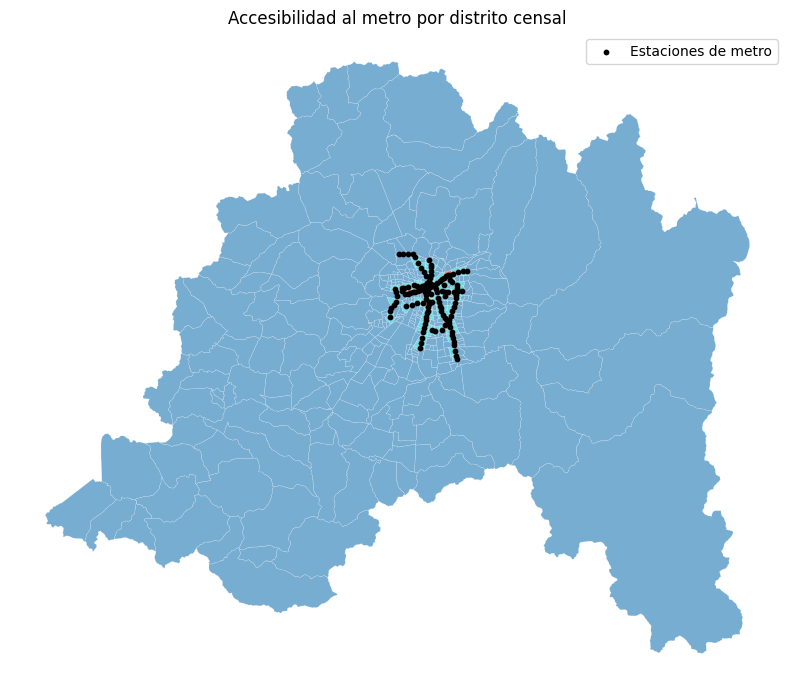

In [37]:
fig, ax = plt.subplots(figsize=(10, 10))

# meterle colores fijos a cada nivel de accesibilidad
distritos["color_acc"] = distritos["nivel_acc"].map({
    "Muy baja": "lightgray",
    "Baja": "yellow",
    "Media": "orange",
    "Alta": "red"
})
distritos.plot(
    column="color_acc",
    legend=True,
    alpha=0.6,
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

estaciones.plot(
    ax=ax,
    color="black",
    markersize=10,
    label="Estaciones de metro"
)

import matplotlib.patches as mpatches
legend_elements = [
    mpatches.Patch(color="lightgray", label="Muy baja"),
    mpatches.Patch(color="yellow", label="Baja"),
    mpatches.Patch(color="orange", label="Media"),
    mpatches.Patch(color="red", label="Alta")
]

ax.legend(handles=legend_elements, title="Nivel de accesibilidad")
plt.title("Accesibilidad al metro por distrito censal")
plt.axis("off")
plt.legend()
plt.show()

Se ve poco, así que lo hacemos para solo Santiago Urbano, usando un overlay espacial para quedarnos solo con los distritos que se intersectan con el área urbana de Santiago.

In [38]:
distritos_urbanos = gpd.overlay(distritos, santiago_urbano, how="intersection")

In [39]:
estaciones_urbanas = gpd.sjoin(estaciones, santiago_urbano, predicate="within")

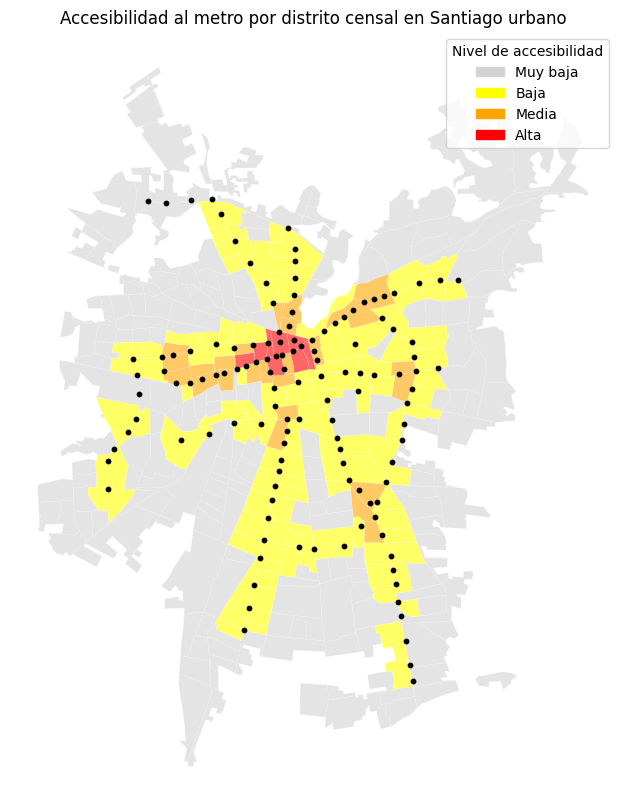

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))

distritos_urbanos["color_acc"] = distritos_urbanos["nivel_acc"].map({
    "Muy baja": "lightgray",
    "Baja": "yellow",
    "Media": "orange",
    "Alta": "red"
})

distritos_urbanos.plot(
    color=distritos_urbanos["color_acc"],
    alpha=0.6,
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

estaciones_urbanas.plot(
    ax=ax,
    color="black",
    markersize=10,
    label="Estaciones de metro"
)

ax.legend(handles=legend_elements, title="Nivel de accesibilidad")
plt.title("Accesibilidad al metro por distrito censal en Santiago urbano")
plt.axis("off")
plt.show()

Como nota, overlay se utiliza cuando necesitas crear nuevas geometrías a partir de la interacción espacial entre capas, mientras que sjoin se usa cuando solo necesitas relacionar información entre capas sin modificar sus formas.

## Parte 2

### a) Grafique en un mapa los distritos censales ubicados en el area urbana de la Region Metropolitana, que pertenecen ademas a la provincia con mas distritos, utilizando una escala de colores basada en una metrica de diversidad de nivel socioeconomico, propuesta por usted.

1. Encontrar la provincia con más distritos

In [41]:
distritos["NOM_PROV"].value_counts()

NOM_PROV
Santiago      312
Melipilla      41
Maipo          34
Cordillera     26
Talagante      20
Chacabuco      16
Name: count, dtype: int64

In [42]:
provincia_top = distritos["NOM_PROV"].value_counts().idxmax()
print(provincia_top)

Santiago


2. Filtrar solo la provincia con más distritos

In [43]:
distritos_objetivo = distritos_urbanos[distritos_urbanos["NOM_PROV"] == provincia_top].copy()

Métrica propuesta: índice de Shannon 

No tiene que ser esta ni tienen que saberla. Yo busqué un rato y me pareció interesante, pero pueden usar cualquier métrica que les parezca relevante para medir la diversidad socioeconómica de los distritos

In [44]:
cols_nse = ["E", "D", "C3", "C2", "ABC1"]

distritos_objetivo["total_nse"] = distritos_objetivo[cols_nse].sum(axis=1)

for col in cols_nse:
    distritos_objetivo[f"p_{col}"] = distritos_objetivo[col] / distritos_objetivo["total_nse"]

import numpy as np

def shannon(row):
    props = [row[f"p_{col}"] for col in cols_nse]
    props = [p for p in props if p > 0]
    return -sum(p * np.log(p) for p in props)

distritos_objetivo["diversidad_nse"] = distritos_objetivo.apply(shannon, axis=1)

más alto = más diversidad socioeconómica, más bajo = más homogeneidad socioeconómica

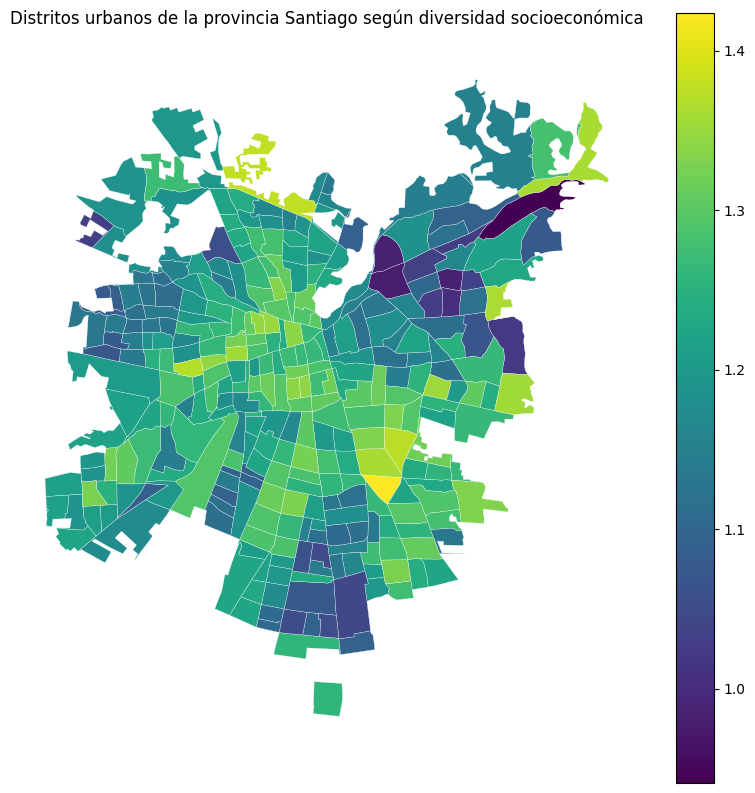

In [45]:
fig, ax = plt.subplots(figsize=(10, 10))

distritos_objetivo.plot(
    column="diversidad_nse",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

plt.title(f"Distritos urbanos de la provincia {provincia_top} según diversidad socioeconómica")
plt.axis("off")
plt.show()

### b) Encuentre las estaciones de metro que tengan 3 o mas distritos censales a menos de 100 metros de distancia.

Asegurar CRS en metros, por si acaso.

In [46]:
estaciones = estaciones.to_crs(epsg=32719)
distritos = distritos.to_crs(epsg=32719)

Buffer de 100 m en estaciones

In [47]:

estaciones["buffer_100m"] = estaciones.geometry.buffer(100)
buffers_est = estaciones.set_geometry("buffer_100m").copy()

Join espacial con distritos

In [48]:

join = gpd.sjoin(distritos, buffers_est, predicate="intersects")

Contar distritos distintos por estación (clave: CODIGO único). Aquí agrupa por Línea y nombre, luego selecciona la columna CODIGO y cuenta los valores únicos. Esto nos dará el número de distritos distintos que están a menos de 100 metros de cada estación.

In [49]:
conteo = (
    join.groupby(["LINEA", "NOMBRE"])["CODIGO"]
    .nunique()
    .sort_values(ascending=False)
)

Filtrar estaciones con 3 o más distritos cercanos

In [50]:
estaciones_3omas = conteo[conteo >= 3]

print("Estaciones con 3 o más distritos a menos de 100m:\n")
print(estaciones_3omas)

Estaciones con 3 o más distritos a menos de 100m:

LINEA  NOMBRE               
L4     Grecia                   5
L5     Blanqueado               4
L2     Lo Martínez              4
L1     Estación Central         4
COMB   Cal y Canto              4
       Ñuñoa                    4
L4A    Santa Rosa               4
L2     Observatorio             4
L4     Elisa Correa             4
       Francisco Bilbao         4
COMB   San Pablo                4
L2     Hospital El Pino         4
COMB   Plaza Egaña              4
L5     Pudahuel                 4
COMB   Los Heroes               4
       La Cisterna              4
L6     Bio Bio                  4
L2     El Parrón                4
       Lo Espejo                3
       Parque O´higgins         3
       Rondizzoni               3
       Zapadores                3
L3     Hospitales               3
L4     Cristobal Colón          3
L3     EFE Quilicura            3
L4     Macul                    3
       Los Presidentes          3
  

Visualización

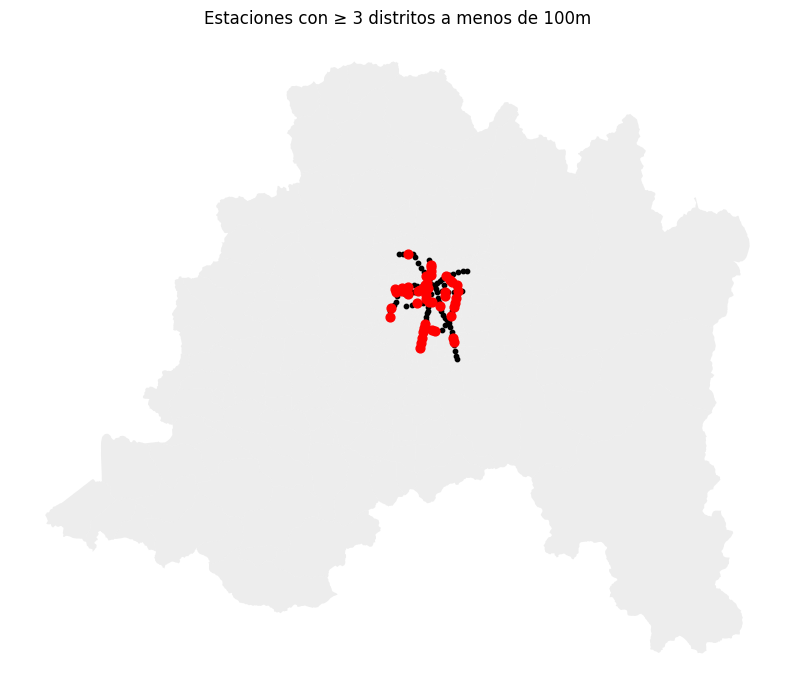

In [51]:
nombres_validos = estaciones_3omas.reset_index()["NOMBRE"]
estaciones_filtradas = estaciones[estaciones["NOMBRE"].isin(nombres_validos)]

fig, ax = plt.subplots(figsize=(10,10))

# distritos de fondo
distritos.plot(ax=ax, color="lightgray", alpha=0.4)

# todas las estaciones
estaciones.plot(ax=ax, color="black", markersize=10)

# estaciones que cumplen condicion
estaciones_filtradas.plot(ax=ax, color="red", markersize=40)

plt.title("Estaciones con ≥ 3 distritos a menos de 100m")
plt.axis("off")
plt.show()

Para mirar mejor, lo hacemos para Santiago Urbano.

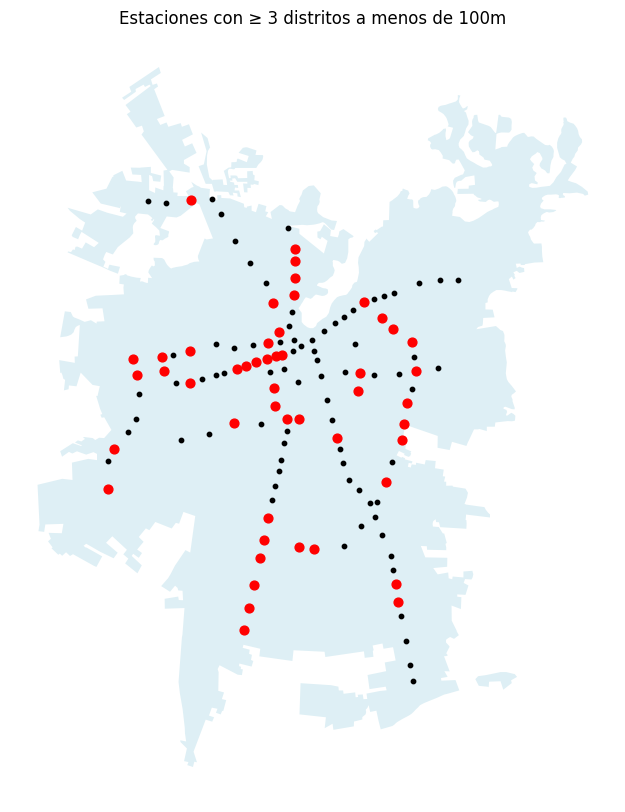

In [52]:
fig, ax = plt.subplots(figsize=(10,10))

# santiago urbano de fondo
santiago_urbano.plot(ax=ax, color="lightblue", alpha=0.4)

# todas las estaciones
estaciones.plot(ax=ax, color="black", markersize=10)

# estaciones que cumplen condición
estaciones_filtradas.plot(ax=ax, color="red", markersize=40)

plt.title("Estaciones con ≥ 3 distritos a menos de 100m")
plt.axis("off")
plt.show()

Se generó un buffer de 100 metros en torno a cada estación de metro y se identificaron los distritos censales que intersectan dichas áreas mediante un join espacial. Luego, se contabilizó el número de distritos distintos asociados a cada estación y se seleccionaron aquellas que presentan tres o más distritos en su entorno inmediato.

### c) Haga un ranking de las comunas con mas estaciones de metro. Visualice esta informacion mediante una tabla y un mapa

In [53]:
comunas = gpd.read_file('datos_geoespaciales/Comunas/Comunas.shp')

In [54]:

estaciones = estaciones.to_crs(epsg=32719)
comunas = comunas.to_crs(epsg=32719)

join = gpd.sjoin(estaciones, comunas, predicate="within")

ranking = (
    join.groupby("Comuna")["NOMBRE"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="n_estaciones")
)

print("Ranking de comunas con más estaciones de metro:\n")
print(ranking)


Ranking de comunas con más estaciones de metro:

                 Comuna  n_estaciones
0              Santiago            20
1           Providencia            10
2            La Florida             9
3                 Ñuñoa             8
4              Recoleta             7
5            Las Condes             7
6      Estación Central             6
7              Lo Prado             5
8                 Macul             5
9                 Maipú             5
10           San Miguel             5
11          Puente Alto             5
12          La Cisterna             4
13             La Reina             4
14            Quilicura             4
15             Conchalí             3
16            Peñalolén             3
17          San Joaquín             2
18        Quinta Normal             2
19            Cerrillos             2
20             Pudahuel             2
21            La Granja             2
22        Independencia             2
23            El Bosque             2
2

Unir ranking a la capa de comunas

In [55]:
comunas_rank = comunas.merge(ranking, on="Comuna", how="left")
comunas_rank["n_estaciones"] = comunas_rank["n_estaciones"].fillna(0)

In [56]:
comunas_rank.sort_values("n_estaciones", ascending=False).head(5)

,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry,n_estaciones
10,333,24644.018619,10,7,13101,13,3.337678e+07,29171.609500,Región Metropolitana de Santiago,Santiago,Santiago,"POLYGON ((346448.311 6299587.312, 347032.628 6...",20.0
6,324,16072.408276,10,7,13123,13,2.073083e+07,19223.740933,Región Metropolitana de Santiago,Providencia,Santiago,"POLYGON ((352667.982 6299779.22, 352705.413 62...",10.0
24,311,49696.426793,12,7,13110,13,1.025245e+08,59570.561221,Región Metropolitana de Santiago,La Florida,Santiago,"POLYGON ((366277.23 6293233.79, 366389.722 629...",9.0
33,321,17714.126051,10,7,13120,13,2.436772e+07,21422.185446,Región Metropolitana de Santiago,Ñuñoa,Santiago,"POLYGON ((353480.118 6295468.647, 353451.683 6...",8.0
27,315,51230.563241,11,7,13114,13,1.416658e+08,61618.090148,Región Metropolitana de Santiago,Las Condes,Santiago,"POLYGON ((357467.636 6305295.665, 357467.932 6...",7.0


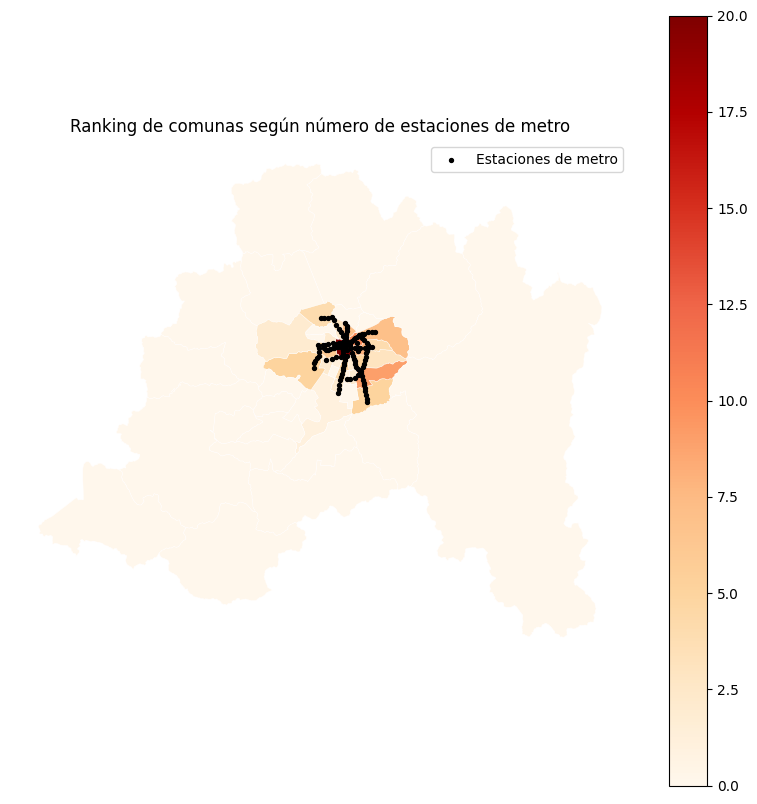

In [57]:
fig, ax = plt.subplots(figsize=(10, 10))

comunas_rank.plot(
    column="n_estaciones",
    cmap="OrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

estaciones.plot(
    ax=ax,
    color="black",
    markersize=8,
    label="Estaciones de metro"
)

plt.title("Ranking de comunas según número de estaciones de metro")
plt.axis("off")
plt.legend()
plt.show()

In [58]:
comunas_urbanas = gpd.overlay(comunas_rank, santiago_urbano, how="intersection")
estaciones_urbanas = gpd.sjoin(estaciones, santiago_urbano, predicate="within")

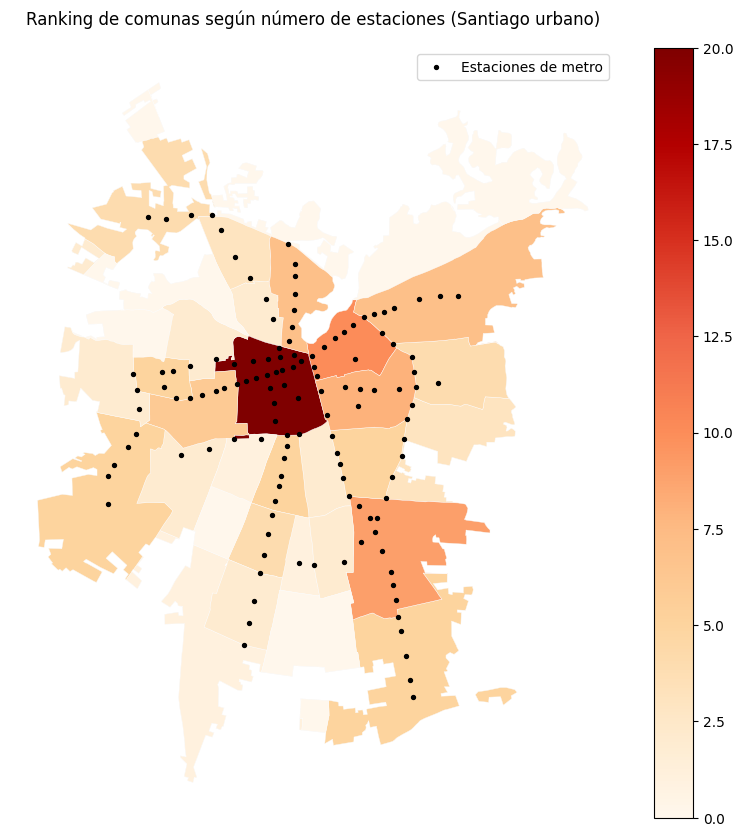

In [59]:
# recortamos comunas al área urbana
comunas_urbanas = gpd.overlay(comunas_rank, santiago_urbano, how="intersection")

# filtramos estaciones dentro de Santiago urbano
estaciones_urbanas = gpd.sjoin(estaciones, santiago_urbano, predicate="within")

fig, ax = plt.subplots(figsize=(10, 10))

# de fondo santiago urbano
santiago_urbano.plot(
    ax=ax,
    color="lightgray",
    edgecolor="none",
    alpha=0.5
)

# comunas urbanas
comunas_urbanas.plot(
    column="n_estaciones",
    cmap="OrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

# estaciones urbanas
estaciones_urbanas.plot(
    ax=ax,
    color="black",
    markersize=8,
    label="Estaciones de metro"
)

plt.title("Ranking de comunas según número de estaciones (Santiago urbano)")
plt.axis("off")
plt.legend()
plt.show()

Nuevamente, 

sjoin -> une atributos según relación espacial (como un JOIN de SQL, por si alguno sabe de bases de datos). Cuando quieres agregar información de una capa a otra sin cambiar geometrías. Por ejemplo, tienes puntos (clientes) y polígonos (comunas). Quieres saber en qué comuna cae cada cliente.

overlay -> crea nuevas geometrías a partir de la intersección/operación espacial. Cuando necesitas modificar o generar nuevas geometrías. Por ejemplo, cortar polígonos por otros polígonos, obtener intersecciones reales.